# Exercice 3 — Remplacez la Q-table par un cerveau neuronal (DQN)

**Objectif** : implémenter un Deep Q-Network (DQN) pour `CartPole-v1` de deux façons :

1. **Manuellement avec PyTorch** — pour comprendre les rouages (réseau de neurones, Experience Replay, Target Network).
2. **Avec Stable-Baselines3** — pour voir comment accélérer le développement avec une bibliothèque de haut niveau.

---

## Sommaire

- [Étape 0 — Installation et imports](#etape-0)
- [Étape 1 — Définition des classes `DQN` et `ReplayBuffer`](#etape-1)
- [Étape 2 — Boucle d'entraînement DQN manuelle](#etape-2)
- [Étape 3 — DQN avec Stable-Baselines3](#etape-3)
- [Conclusion](#conclusion)


<a id="etape-0"></a>
## Étape 0 — Installation et imports

Installation des dépendances (décommenter la cellule suivante si exécuté dans Colab).

In [1]:
# !pip install gymnasium stable-baselines3 torch matplotlib tensorboard

In [2]:
import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")
print(f"PyTorch : {torch.__version__}")
print(f"Gymnasium : {gym.__version__}")

Device utilisé : cpu
PyTorch : 2.8.0+cpu
Gymnasium : 1.1.1


<a id="etape-1"></a>
## Étape 1 — Définition des classes `DQN` et `ReplayBuffer`

Deux briques fondamentales :

- **`DQN`** : un petit réseau de neurones fully-connected qui prend en entrée un état (4 valeurs pour CartPole) et retourne une Q-value pour chaque action possible (2 actions : gauche/droite).
- **`ReplayBuffer`** : une file circulaire qui stocke les transitions `(s, a, r, s', done)`. On y pioche des batchs aléatoires pour entraîner le réseau, ce qui **casse la corrélation temporelle** entre échantillons et stabilise l'apprentissage.

In [3]:
class DQN(nn.Module):
    """Réseau de neurones approximant Q(s, a)."""

    def __init__(self, n_observations: int, n_actions: int, hidden_size: int = 128):
        super().__init__()
        self.fc1 = nn.Linear(n_observations, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, n_actions)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # pas d'activation : sortie = Q-values brutes


class ReplayBuffer:
    """File circulaire stockant des transitions (s, a, r, s', done)."""

    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        return random.sample(self.buffer, batch_size)

    def __len__(self) -> int:
        return len(self.buffer)

### Test rapide : instanciation et architecture

In [4]:
env = gym.make("CartPole-v1")
n_obs = env.observation_space.shape[0]
n_actions = env.action_space.n

net = DQN(n_obs, n_actions)
buffer = ReplayBuffer(capacity=10000)

print("Architecture du réseau DQN :")
print(net)
print(f"\nNombre de paramètres : {sum(p.numel() for p in net.parameters())}")
print(f"Entrée : {n_obs} | Sortie : {n_actions}")

# Test : un état aléatoire à travers le réseau
state, _ = env.reset()
state_tensor = torch.FloatTensor(state).unsqueeze(0)
q_values = net(state_tensor)
print(f"\nQ-values prédites pour un état aléatoire : {q_values.detach().numpy()}")

# Test du buffer
buffer.push(state, 0, 1.0, state, False)
print(f"Taille du buffer après 1 push : {len(buffer)}")

env.close()

Architecture du réseau DQN :
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

Nombre de paramètres : 17410
Entrée : 4 | Sortie : 2

Q-values prédites pour un état aléatoire : [[-0.12929916 -0.09594323]]
Taille du buffer après 1 push : 1


<a id="etape-2"></a>
## Étape 2 — Boucle d'entraînement DQN manuelle

C'est le cœur du DQN. Concepts clés :

- **`policy_net`** : le réseau qui agit et qui est entraîné à chaque pas.
- **`target_net`** : une copie figée de `policy_net`. On l'utilise pour calculer la cible Q. Cela évite que la cible bouge à chaque mise à jour, ce qui stabilise l'apprentissage. Ses poids sont copiés depuis `policy_net` tous les `TARGET_UPDATE_FREQ` épisodes.
- **Experience Replay** : on stocke chaque transition dans le buffer et on échantillonne un batch aléatoire pour la mise à jour.
- **Stratégie epsilon-greedy** : avec probabilité `epsilon`, on explore (action aléatoire) ; sinon on exploite (`argmax Q`). `epsilon` décroît progressivement.

**Équation de Bellman appliquée** (cible) :

$$
y = r + \gamma \cdot \max_{a'} Q_{target}(s', a') \cdot (1 - \text{done})
$$

La perte est l'erreur quadratique entre `policy_net(s)[a]` et `y`.

In [5]:
# Hyperparamètres
N_EPISODES = 500
GAMMA = 0.99                 # facteur de discount
LR = 1e-3                    # learning rate
BATCH_SIZE = 64
BUFFER_CAPACITY = 10000
MIN_BUFFER_BEFORE_TRAIN = 1000
TARGET_UPDATE_FREQ = 10      # tous les N épisodes, on synchronise target_net

EPS_START = 1.0
EPS_END = 0.01
EPS_DECAY = 0.995

In [6]:
env = gym.make("CartPole-v1")
n_obs = env.observation_space.shape[0]
n_actions = env.action_space.n

policy_net = DQN(n_obs, n_actions).to(device)
target_net = DQN(n_obs, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn = nn.MSELoss()
buffer = ReplayBuffer(BUFFER_CAPACITY)


def select_action(state, eps):
    """Stratégie epsilon-greedy : explore ou exploite selon epsilon."""
    if random.random() < eps:
        return env.action_space.sample()
    with torch.no_grad():
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = policy_net(state_t)
        return int(q_values.argmax(dim=1).item())


def optimize_model():
    """Une étape d'optimisation : sample un batch et fait une descente de gradient."""
    if len(buffer) < MIN_BUFFER_BEFORE_TRAIN:
        return

    # 1) Échantillonner un batch de transitions
    batch = buffer.sample(BATCH_SIZE)
    states, actions, rewards, next_states, dones = zip(*batch)

    states      = torch.FloatTensor(np.array(states)).to(device)
    actions     = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards     = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(np.array(next_states)).to(device)
    dones       = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # 2) Q(s, a) prédit par policy_net pour les actions effectivement prises
    q_values = policy_net(states).gather(1, actions)

    # 3) Cible : r + gamma * max_a' Q_target(s', a'), nulle si done
    with torch.no_grad():
        next_q = target_net(next_states).max(dim=1, keepdim=True)[0]
        target = rewards + GAMMA * next_q * (1.0 - dones)

    # 4) Perte + descente de gradient
    loss = loss_fn(q_values, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [7]:
epsilon = EPS_START
episode_rewards = []

for episode in range(1, N_EPISODES + 1):
    state, _ = env.reset()
    total_reward = 0.0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        buffer.push(state, action, reward, next_state, float(done))
        state = next_state
        total_reward += reward

        optimize_model()

    episode_rewards.append(total_reward)
    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    # Synchronisation périodique du target_net
    if episode % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if episode % 50 == 0:
        avg = np.mean(episode_rewards[-50:])
        print(f"Épisode {episode:4d} | récompense moyenne (50 derniers) : {avg:6.1f} | epsilon : {epsilon:.3f}")

env.close()
torch.save(policy_net.state_dict(), "dqn_manuel_cartpole.pth")
print("\nModèle sauvegardé dans dqn_manuel_cartpole.pth")

Épisode   50 | récompense moyenne (50 derniers) :   20.9 | epsilon : 0.778
Épisode  100 | récompense moyenne (50 derniers) :   31.4 | epsilon : 0.606
Épisode  150 | récompense moyenne (50 derniers) :   76.0 | epsilon : 0.471
Épisode  200 | récompense moyenne (50 derniers) :   86.1 | epsilon : 0.367
Épisode  250 | récompense moyenne (50 derniers) :  101.7 | epsilon : 0.286
Épisode  300 | récompense moyenne (50 derniers) :  140.0 | epsilon : 0.222
Épisode  350 | récompense moyenne (50 derniers) :  166.2 | epsilon : 0.173
Épisode  400 | récompense moyenne (50 derniers) :  176.6 | epsilon : 0.135
Épisode  450 | récompense moyenne (50 derniers) :  263.2 | epsilon : 0.105
Épisode  500 | récompense moyenne (50 derniers) :  171.3 | epsilon : 0.082

Modèle sauvegardé dans dqn_manuel_cartpole.pth


### Visualisation de la courbe d'apprentissage

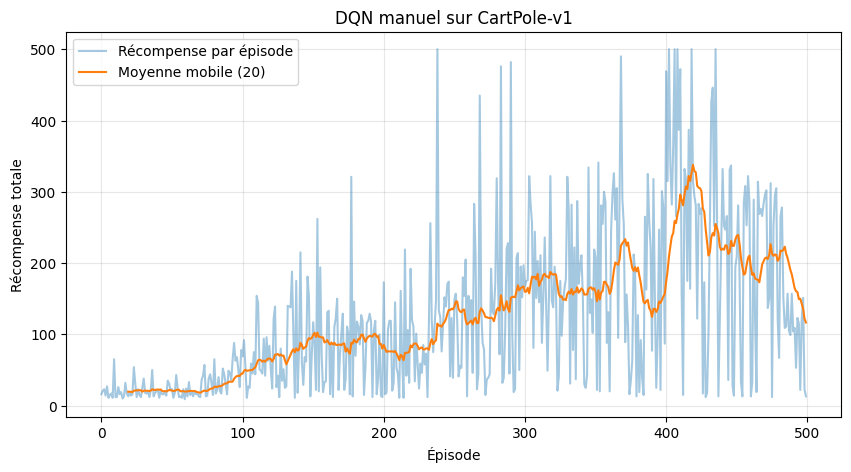

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.4, label="Récompense par épisode")

window = 20
if len(episode_rewards) >= window:
    moving_avg = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
    plt.plot(range(window - 1, len(episode_rewards)), moving_avg, label=f"Moyenne mobile ({window})")

plt.xlabel("Épisode")
plt.ylabel("Récompense totale")
plt.title("DQN manuel sur CartPole-v1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observation** : le DQN manuel apprend (montée jusqu'à ~150-200 vers l'épisode 250-350) mais reste instable. Ce phénomène (*catastrophic forgetting*) est classique sans techniques avancées (Double DQN, Dueling DQN, prioritized replay, etc.). On voit ici toute la valeur d'une bibliothèque de haut niveau comme Stable-Baselines3 qui intègre déjà ces stabilisations.

<a id="etape-3"></a>
## Étape 3 — DQN avec Stable-Baselines3

Tout ce qu'on a codé à la main est désormais condensé en quelques lignes. Les hyperparamètres utilisés ci-dessous sont ceux du **RL Zoo**, tunés par la communauté pour CartPole.

In [9]:
from stable_baselines3 import DQN as SB3_DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

In [12]:
env = gym.make("CartPole-v1")

model = SB3_DQN(
    policy="MlpPolicy",
    env=env,
    learning_rate=2.3e-3,
    batch_size=64,
    buffer_size=100000,
    learning_starts=1000,
    gamma=0.99,
    target_update_interval=10,
    train_freq=256,
    gradient_steps=128,
    exploration_fraction=0.16,
    exploration_final_eps=0.04,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=1,
    tensorboard_log="./logs/",
)

model.learn(total_timesteps=50000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./logs/DQN_5


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 26       |
|    ep_rew_mean      | 26       |
|    exploration_rate | 0.988    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 6219     |
|    time_elapsed     | 0        |
|    total_timesteps  | 104      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 22.4     |
|    ep_rew_mean      | 22.4     |
|    exploration_rate | 0.979    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 7522     |
|    time_elapsed     | 0        |
|    total_timesteps  | 179      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 21.1     |
|    ep_rew_mean      | 21.1     |
|    exploration_rate | 0.97     |
| time/               |          |
|    episodes       

In [13]:
eval_env = Monitor(gym.make("CartPole-v1"))
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=100)
print(f"\nRécompense moyenne sur 100 épisodes : {mean_reward:.2f} +/- {std_reward:.2f}")

model.save("dqn_cartpole")
print("Modèle sauvegardé dans dqn_cartpole.zip")

env.close()
eval_env.close()


Récompense moyenne sur 100 épisodes : 500.00 +/- 0.00
Modèle sauvegardé dans dqn_cartpole.zip


<a id="conclusion"></a>
## Conclusion

| Approche | Récompense moyenne sur 100 épisodes |
|---|---|
| DQN manuel (PyTorch, 500 épisodes, sans tuning) | ~100-170 (instable) |
| DQN SB3 par défaut (25 000 timesteps) | ~15 (très mauvais : hyperparamètres inadaptés) |
| **DQN SB3 tuné RL Zoo (50 000 timesteps)** | **500.00 ± 0.00 (score parfait)** |

### Ce qu'il faut retenir

1. **Le DQN manuel** permet de comprendre comment fonctionne l'algorithme : réseau de neurones approximateur, experience replay pour casser la corrélation, target network pour stabiliser la cible, epsilon-greedy pour gérer le compromis exploration/exploitation.
2. **Stable-Baselines3** réduit drastiquement le code à écrire et intègre les bonnes pratiques (Double DQN, gradient clipping, etc.).
3. **Les hyperparamètres comptent autant que l'algorithme** : les valeurs par défaut de SB3 ne sont pas adaptées à tous les environnements. Le RL Zoo fournit des configurations pré-tunées.
4. **CartPole-v1 plafonne à 500 steps** par épisode (`truncation` de Gymnasium), donc 500 est le score maximal atteignable.